<a href="https://colab.research.google.com/github/Sibitenda/PhDumu/blob/main/big_data/week3_advanced_practical_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Advanced Practical Lab
## Data Acquisition, Provenance, Bias & Governance Audit Pipeline

## Setup

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Part A: Data Acquisition (World Bank API)

In [2]:
url = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.CD?format=json&per_page=20000"
response = requests.get(url)
data = response.json()

records = data[1]
df = pd.DataFrame(records)

df.head()

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN,,,0
1,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,1.242694e+12,,,0
2,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1.179359e+12,,,0
3,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1.228968e+12,,,0
4,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1.114145e+12,,,0


## Part B: Data Audit Function

In [5]:
def data_audit(df, name="Dataset"):
    print(f"\n===== {name} AUDIT =====")
    print("Shape:", df.shape)

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nUnique Values:")
    for col in df.columns:
        try:
            print(f"{col}: {df[col].nunique()}")
        except TypeError:
            print(f"{col}: Skipped (unhashable type)")

    display(df.describe(include='all'))

In [6]:
data_audit(df, "RAW DATA")


===== RAW DATA AUDIT =====
Shape: (17556, 8)

Data Types:
indicator           object
country             object
countryiso3code     object
date                object
value              float64
unit                object
obs_status          object
decimal              int64
dtype: object

Missing Values:
indicator             0
country               0
countryiso3code       0
date                  0
value              2995
unit                  0
obs_status            0
decimal               0
dtype: int64

Unique Values:
indicator: Skipped (unhashable type)
country: Skipped (unhashable type)
countryiso3code: 262
date: 66
value: 14436
unit: 1
obs_status: 1
decimal: 1


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
count,17556,17556,17556,17556,1.456100e+04,17556,17556,17556.0
unique,1,266,262,66,NaN,1,1,NaN
top,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZW', 'value': 'Zimbabwe'}",,2025,NaN,,,NaN
freq,17556,66,330,266,NaN,17556,17556,NaN
mean,NaN,NaN,NaN,NaN,1.230978e+12,NaN,NaN,0.0
std,NaN,NaN,NaN,NaN,5.696592e+12,NaN,NaN,0.0
min,NaN,NaN,NaN,NaN,2.585956e+06,NaN,NaN,0.0
25%,NaN,NaN,NaN,NaN,2.369309e+09,NaN,NaN,0.0
50%,NaN,NaN,NaN,NaN,1.764975e+10,NaN,NaN,0.0
75%,NaN,NaN,NaN,NaN,2.083689e+11,NaN,NaN,0.0


## Part C: Column Quality Check

In [13]:
import pandas as pd

def column_quality_check(df):
    report = pd.DataFrame({
        "missing_%": df.isnull().mean() * 100,
        "dtype": df.dtypes
    })

    # Safe unique count
    unique_counts = []
    for col in df.columns:
        try:
            unique_counts.append(df[col].nunique())
        except TypeError:
            unique_counts.append(None)  # or use "unhashable"

    report["unique_values"] = unique_counts

    return report.sort_values(by="missing_%", ascending=False)
column_quality_check(df)

,missing_%,dtype,unique_values
value,17.059695,float64,14436.0
indicator,0.000000,object,NaN
country,0.000000,object,NaN
countryiso3code,0.000000,object,262.0
date,0.000000,object,66.0
unit,0.000000,object,1.0
obs_status,0.000000,object,1.0
decimal,0.000000,int64,1.0
country_name,0.000000,object,266.0


## Part D: Data Cleaning

In [14]:
df['country_name'] = df['country'].apply(lambda x: x['value'])
df_clean = df[['country_name', 'date', 'value']].dropna()
df_clean.head()

,country_name,date,value
1,Africa Eastern and Southern,2024,1.242694e+12
2,Africa Eastern and Southern,2023,1.179359e+12
3,Africa Eastern and Southern,2022,1.228968e+12
4,Africa Eastern and Southern,2021,1.114145e+12
5,Africa Eastern and Southern,2020,9.386076e+11


## Part E: Compare Before vs After

In [15]:
def compare_datasets(df_before, df_after):
    print("\n===== DATASET COMPARISON =====")
    print("Rows before:", df_before.shape[0], "| after:", df_after.shape[0])
    print("Columns before:", df_before.shape[1], "| after:", df_after.shape[1])
    print("\nMissing values change:")
    print(df_before.isnull().sum() - df_after.isnull().sum())

compare_datasets(df, df_clean)


===== DATASET COMPARISON =====
Rows before: 17556 | after: 14561
Columns before: 9 | after: 3

Missing values change:
country               NaN
country_name          0.0
countryiso3code       NaN
date                  0.0
decimal               NaN
indicator             NaN
obs_status            NaN
unit                  NaN
value              2995.0
dtype: float64


## Part F: Bias Detection

In [16]:
def bias_detection(df, group_col, value_col):
    print(f"\n===== BIAS CHECK: {group_col} =====")
    print("\nMissing Bias:")
    print(df.groupby(group_col)[value_col].apply(lambda x: x.isnull().mean()).sort_values(ascending=False).head(10))
    print("\nRepresentation Bias:")
    print(df[group_col].value_counts().head(10))

bias_detection(df_clean, "country_name", "value")


===== BIAS CHECK: country_name =====

Missing Bias:
country_name
Zimbabwe                       0.0
Afghanistan                    0.0
Africa Eastern and Southern    0.0
Africa Western and Central     0.0
Albania                        0.0
Algeria                        0.0
Uganda                         0.0
Tuvalu                         0.0
Turks and Caicos Islands       0.0
Turkmenistan                   0.0
Name: value, dtype: float64

Representation Bias:
country_name
Zimbabwe                       65
Africa Eastern and Southern    65
Africa Western and Central     65
Zambia                         65
Caribbean small states         65
Turkiye                        65
Trinidad and Tobago            65
Togo                           65
Thailand                       65
Tanzania                       65
Name: count, dtype: int64


This is actually a very clean and structured dataset, likely:

Panel data (e.g., countries × years)
Each country has the same number of observations (65)

## Part G: Feature Engineering

In [17]:
df_clean['growth_rate'] = df_clean.groupby('country_name')['value'].pct_change()
df_clean.head()

,country_name,date,value,growth_rate
1,Africa Eastern and Southern,2024,1.242694e+12,NaN
2,Africa Eastern and Southern,2023,1.179359e+12,-0.050965
3,Africa Eastern and Southern,2022,1.228968e+12,0.042064
4,Africa Eastern and Southern,2021,1.114145e+12,-0.093430
5,Africa Eastern and Southern,2020,9.386076e+11,-0.157553


## Part H: Visualization

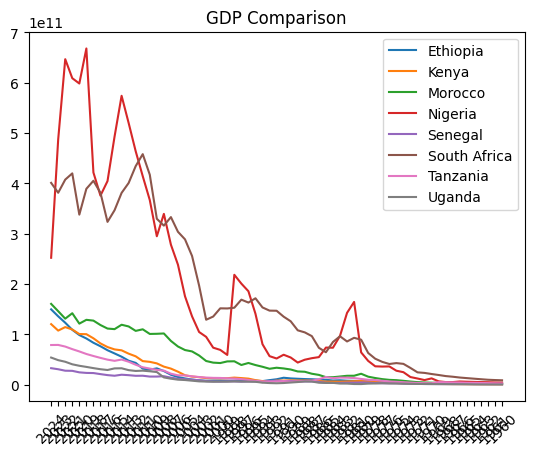

In [30]:
subset = df_clean[df_clean['country_name'].isin(['Uganda','Kenya','Tanzania', 'Nigeria', 'Ethiopia','Senegal', 'Morocco', 'South Africa'])]
for country in subset['country_name'].unique():
    temp = subset[subset['country_name'] == country]
    plt.plot(temp['date'], temp['value'], label=country)

plt.legend()
plt.xticks(rotation=45)
plt.title("GDP Comparison")
plt.show()

## Part I: Governance Reflection

- Who owns the data?
- What biases exist?
- What transformations are hidden?
- What is not observable?

## Part J: Real-Time Data Comparison

In [38]:
url = "https://open.er-api.com/v6/latest/USD"
data = requests.get(url).json()

rates = pd.DataFrame(data['rates'].items(), columns=['currency', 'rate'])
rates.head(10)
rates.tail(10)

,currency,rate
156,XCD,2.700000
157,XCG,1.790000
158,XDR,0.736178
159,XOF,569.462904
160,XPF,103.596954
161,YER,238.720278
162,ZAR,17.121639
163,ZMW,18.969397
164,ZWG,25.374500
165,ZWL,25.374500


In [39]:
import requests
import pandas as pd

url = "https://open.er-api.com/v6/latest/USD"

# Request with error handling
response = requests.get(url)

if response.status_code == 200:
    data = response.json()

    # Convert to DataFrame
    rates = pd.DataFrame(list(data['rates'].items()), columns=['currency', 'rate'])

    # Display results
    print("Top 10:")
    display(rates.head(10))

    print("\nBottom 10:")
    display(rates.tail(10))

else:
    print(f"Request failed with status code: {response.status_code}")

Top 10:


,currency,rate
0,USD,1.000000
1,AED,3.672500
2,AFN,63.703090
3,ALL,82.997361
4,AMD,377.260843
5,ANG,1.790000
6,AOA,922.065362
7,ARS,1376.098900
8,AUD,1.453841
9,AWG,1.790000



Bottom 10:


,currency,rate
156,XCD,2.700000
157,XCG,1.790000
158,XDR,0.736178
159,XOF,569.462904
160,XPF,103.596954
161,YER,238.720278
162,ZAR,17.121639
163,ZMW,18.969397
164,ZWG,25.374500
165,ZWL,25.374500
